Step 1: Install Required Libraries

In [1]:
!pip install -q avalanche-lib

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.2/134.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 993.4/993.4 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 585.2/585.2 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.5/869.5 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 534.6/534.6 kB 38.1 MB/s eta 0:00:00


Step 2: Import Libraries

In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import transforms

from avalanche.benchmarks.classic import SplitCIFAR10
from avalanche.training.supervised import Naive, EWC
from avalanche.training.plugins import EvaluationPlugin
from avalanche.evaluation.metrics import accuracy_metrics, loss_metrics, forgetting_metrics
from avalanche.logging import InteractiveLogger

Step 3: Setup Device, Seed, and Dataset

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

benchmark = SplitCIFAR10(
    n_experiences=5,
    seed=SEED,
    return_task_id=False,
    train_transform=transform,
    eval_transform=transform
)

print("✓ Dataset loaded successfully")
print("Training experiences:", len(benchmark.train_stream))
print("Test experiences:", len(benchmark.test_stream))

for i, exp in enumerate(benchmark.train_stream):
    print(f"Train experience {i}: classes {exp.classes_in_this_experience}")

Using device: cpu


100%|██████████| 170M/170M [00:02<00:00, 74.6MB/s]


✓ Dataset loaded successfully
Training experiences: 5
Test experiences: 5
Train experience 0: classes [2, 6]
Train experience 1: classes [8, 1]
Train experience 2: classes [4, 5]
Train experience 3: classes [0, 9]
Train experience 4: classes [3, 7]


Step 4: Define CNN Model

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16x16 -> 8x8
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Step 5: Setup Evaluation Plugin

In [5]:
interactive_logger = InteractiveLogger()

eval_plugin = EvaluationPlugin(
    accuracy_metrics(minibatch=False, epoch=True, experience=True, stream=True),
    loss_metrics(minibatch=False, epoch=True, experience=True, stream=True),
    forgetting_metrics(experience=True, stream=True),
    loggers=[interactive_logger]
)

print("✓ Evaluation plugin ready")


✓ Evaluation plugin ready


Step 6: Define Reusable Training Function

In [6]:
def train_and_evaluate(strategy, benchmark, strategy_name="Strategy"):
    print("=" * 80)
    print(f"STARTING CONTINUAL LEARNING TRAINING ({strategy_name})")
    print("=" * 80)

    results = {
        "task_id": [],
        "stream_acc": [],
        "stream_loss": []
    }

    for task_id, experience in enumerate(benchmark.train_stream):
        print(f"\n{'=' * 80}")
        print(f"{strategy_name} - TASK {task_id}: Classes {experience.classes_in_this_experience}")
        print(f"{'=' * 80}")

        print(f"Training for {strategy.train_epochs} epochs...")
        strategy.train(experience)

        print(f"\nEvaluating on tasks 0 to {task_id}...")
        eval_results = strategy.eval(benchmark.test_stream[:task_id + 1])

        stream_acc = None
        stream_loss = None

        for k, v in eval_results.items():
            if "Top1_Acc_Stream/eval_phase/test_stream" in k:
                stream_acc = v
            if "Loss_Stream/eval_phase/test_stream" in k:
                stream_loss = v

        results["task_id"].append(task_id)
        results["stream_acc"].append(stream_acc)
        results["stream_loss"].append(stream_loss)

        print(f"✓ {strategy_name} Task {task_id} complete!")
        print(f"Current stream accuracy: {stream_acc}")
        print(f"Current stream loss: {stream_loss}")

    print("\n" + "=" * 80)
    print(f"{strategy_name} TRAINING COMPLETE!")
    print("=" * 80)

    return pd.DataFrame(results)

Step 7: Train Naive Baseline

In [7]:
# Fresh model for Naive
naive_model = SimpleCNN().to(device)
naive_optimizer = optim.Adam(naive_model.parameters(), lr=1e-3)

naive_strategy = Naive(
    model=naive_model,
    optimizer=naive_optimizer,
    criterion=nn.CrossEntropyLoss(),
    train_mb_size=64,
    train_epochs=3,
    eval_mb_size=64,
    device=device,
    evaluator=eval_plugin
)

naive_results = train_and_evaluate(
    strategy=naive_strategy,
    benchmark=benchmark,
    strategy_name="Naive"
)

STARTING CONTINUAL LEARNING TRAINING (Naive)

Naive - TASK 0: Classes [2, 6]
Training for 3 epochs...
-- >> Start of training phase << --
100%|██████████| 157/157 [00:20<00:00,  7.84it/s]
Epoch 0 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 0.4905
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.7663
100%|██████████| 157/157 [00:18<00:00,  8.60it/s]
Epoch 1 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 0.3510
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8485
100%|██████████| 157/157 [00:18<00:00,  8.45it/s]
Epoch 2 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 0.2844
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8845
-- >> End of training phase << --

Evaluating on tasks 0 to 0...
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|██████████| 32/32 [00:01<00:00, 16.71it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 0.2688
	Top1_Acc_E

Step 8: Plot Graph for Naive

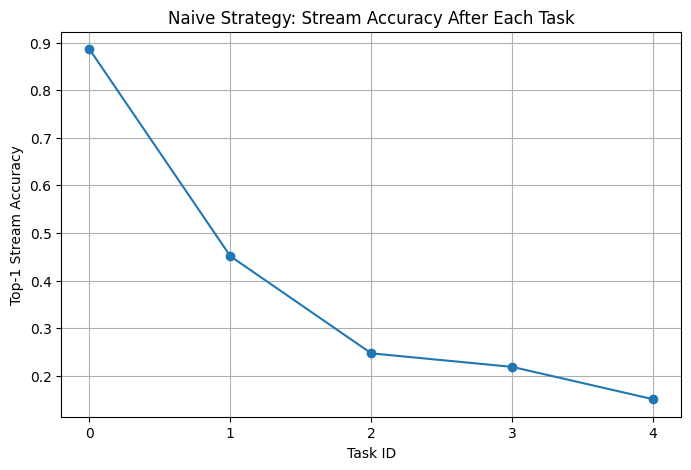

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(naive_results["task_id"], naive_results["stream_acc"], marker="o")
plt.title("Naive Strategy: Stream Accuracy After Each Task")
plt.xlabel("Task ID")
plt.ylabel("Top-1 Stream Accuracy")
plt.xticks(naive_results["task_id"])
plt.grid(True)
plt.show()

Naive loss graph:

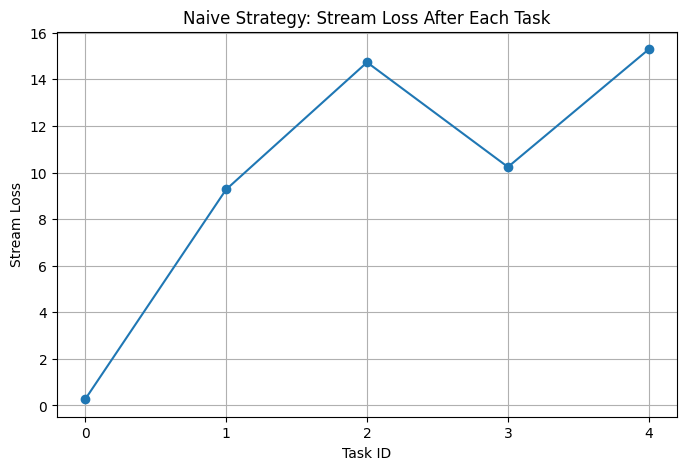

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(naive_results["task_id"], naive_results["stream_loss"], marker="o")
plt.title("Naive Strategy: Stream Loss After Each Task")
plt.xlabel("Task ID")
plt.ylabel("Stream Loss")
plt.xticks(naive_results["task_id"])
plt.grid(True)
plt.show()

Step 9: Train EWC

In [11]:
# Fresh model for EWC
ewc_model = SimpleCNN().to(device)
ewc_optimizer = optim.Adam(ewc_model.parameters(), lr=1e-3)

ewc_strategy = EWC(
    model=ewc_model,
    optimizer=ewc_optimizer,
    criterion=nn.CrossEntropyLoss(),
    train_mb_size=64,
    train_epochs=3,
    eval_mb_size=64,
    device=device,
    evaluator=eval_plugin,
    ewc_lambda=1.0,
    mode="separate"
)

ewc_results = train_and_evaluate(
    strategy=ewc_strategy,
    benchmark=benchmark,
    strategy_name="EWC"
)

STARTING CONTINUAL LEARNING TRAINING (EWC)

EWC - TASK 0: Classes [2, 6]
Training for 3 epochs...
-- >> Start of training phase << --
182it [09:04,  2.99s/it]
Epoch 0 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 0.4942
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.7725
100%|██████████| 157/157 [00:19<00:00,  8.02it/s]
Epoch 1 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 0.3505
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8489
100%|██████████| 157/157 [00:17<00:00,  8.84it/s]
Epoch 2 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 0.2881
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8802
-- >> End of training phase << --

Evaluating on tasks 0 to 0...
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|██████████| 32/32 [00:02<00:00, 12.56it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	Loss_Exp/eval_phase/test_stream/Task000/Exp000 = 0.3016
	Top1_Acc_Exp/eval_phase/test_stream/Tas

Step 10: Plot Graph for EWC

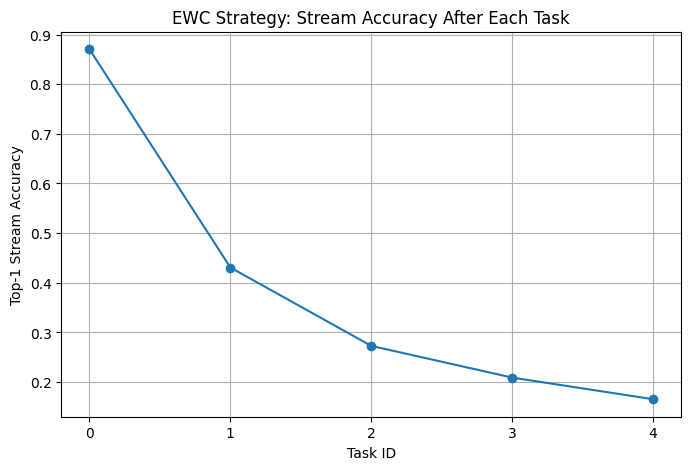

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(ewc_results["task_id"], ewc_results["stream_acc"], marker="o")
plt.title("EWC Strategy: Stream Accuracy After Each Task")
plt.xlabel("Task ID")
plt.ylabel("Top-1 Stream Accuracy")
plt.xticks(ewc_results["task_id"])
plt.grid(True)
plt.show()

EWC loss graph:

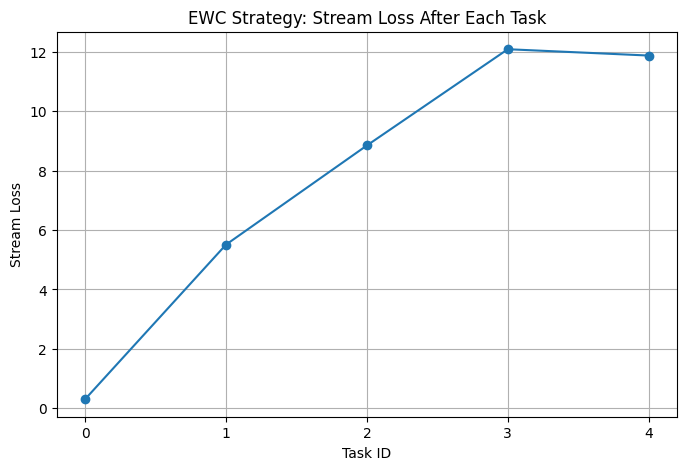

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(ewc_results["task_id"], ewc_results["stream_loss"], marker="o")
plt.title("EWC Strategy: Stream Loss After Each Task")
plt.xlabel("Task ID")
plt.ylabel("Stream Loss")
plt.xticks(ewc_results["task_id"])
plt.grid(True)
plt.show()

Step 11: Import Pruning Library




In [14]:
import torch.nn.utils.prune as prune

Step 12: Adaptive Pruning Function

In [15]:
def adaptive_prune_after_task(model, amount=0.05):
    """
    Apply small incremental global pruning after each task.

    amount=0.05 means prune 5% more weights after each task.
    """
    parameters_to_prune = []

    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            parameters_to_prune.append((module, 'weight'))

    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=amount,
    )

    print(f"✓ Adaptive pruning applied: {amount*100:.0f}% additional pruning")

Step 13: Sparsity Check Function

In [16]:
def check_sparsity(model):
    total_params = 0
    zero_params = 0

    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            weight = module.weight
            total_params += weight.nelement()
            zero_params += torch.sum(weight == 0).item()

    sparsity = 100.0 * zero_params / total_params
    print(f"Model Sparsity: {sparsity:.2f}%")
    return sparsity

Step 14: Adaptive Pruning + EWC Training Function

In [17]:
def train_and_evaluate_adaptive_pruning(strategy, benchmark, model, strategy_name="Adaptive Pruning + EWC"):
    print("=" * 80)
    print(f"STARTING CONTINUAL LEARNING TRAINING ({strategy_name})")
    print("=" * 80)

    results = {
        "task_id": [],
        "stream_acc": [],
        "stream_loss": [],
        "sparsity": []
    }

    for task_id, experience in enumerate(benchmark.train_stream):
        print(f"\n{'=' * 80}")
        print(f"{strategy_name} - TASK {task_id}: Classes {experience.classes_in_this_experience}")
        print(f"{'=' * 80}")

        # Train on current task
        print(f"Training for {strategy.train_epochs} epochs...")
        strategy.train(experience)

        # Evaluate on all tasks seen so far
        print(f"\nEvaluating on tasks 0 to {task_id}...")
        eval_results = strategy.eval(benchmark.test_stream[:task_id + 1])

        stream_acc = None
        stream_loss = None

        for k, v in eval_results.items():
            if "Top1_Acc_Stream/eval_phase/test_stream" in k:
                stream_acc = v
            if "Loss_Stream/eval_phase/test_stream" in k:
                stream_loss = v

        # Apply adaptive pruning after each task
        adaptive_prune_after_task(model, amount=0.05)

        # Measure sparsity
        sparsity = check_sparsity(model)

        results["task_id"].append(task_id)
        results["stream_acc"].append(stream_acc)
        results["stream_loss"].append(stream_loss)
        results["sparsity"].append(sparsity)

        print(f"✓ {strategy_name} Task {task_id} complete!")
        print(f"Current stream accuracy: {stream_acc}")
        print(f"Current stream loss: {stream_loss}")
        print(f"Current sparsity: {sparsity:.2f}%")

    print("\n" + "=" * 80)
    print(f"{strategy_name} TRAINING COMPLETE!")
    print("=" * 80)

    return pd.DataFrame(results)

Step 15: Train Adaptive Pruning + EWC

In [18]:
# Fresh model for Adaptive Pruning + EWC
adaptive_model = SimpleCNN().to(device)
adaptive_optimizer = optim.Adam(adaptive_model.parameters(), lr=1e-3)

adaptive_ewc_strategy = EWC(
    model=adaptive_model,
    optimizer=adaptive_optimizer,
    criterion=nn.CrossEntropyLoss(),
    train_mb_size=64,
    train_epochs=3,
    eval_mb_size=64,
    device=device,
    evaluator=eval_plugin,
    ewc_lambda=1.0,
    mode="separate"
)

adaptive_results = train_and_evaluate_adaptive_pruning(
    strategy=adaptive_ewc_strategy,
    benchmark=benchmark,
    model=adaptive_model,
    strategy_name="Adaptive Pruning + EWC"
)

STARTING CONTINUAL LEARNING TRAINING (Adaptive Pruning + EWC)

Adaptive Pruning + EWC - TASK 0: Classes [2, 6]
Training for 3 epochs...
-- >> Start of training phase << --
100%|██████████| 157/157 [00:18<00:00,  8.35it/s]
Epoch 0 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 0.5057
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.7607
100%|██████████| 157/157 [00:18<00:00,  8.56it/s]
Epoch 1 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 0.3540
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8469
100%|██████████| 157/157 [00:17<00:00,  8.74it/s]
Epoch 2 ended.
	Loss_Epoch/train_phase/train_stream/Task000 = 0.2906
	Top1_Acc_Epoch/train_phase/train_stream/Task000 = 0.8777
-- >> End of training phase << --

Evaluating on tasks 0 to 0...
-- >> Start of eval phase << --
-- Starting eval on experience 0 (Task 0) from test stream --
100%|██████████| 32/32 [00:01<00:00, 16.55it/s]
> Eval on experience 0 (Task 0) from test stream ended.
	Loss_Exp/eval_phase/test_stream/T

Step 16: Plot Accuracy Graph for Adaptive Pruning + EWC

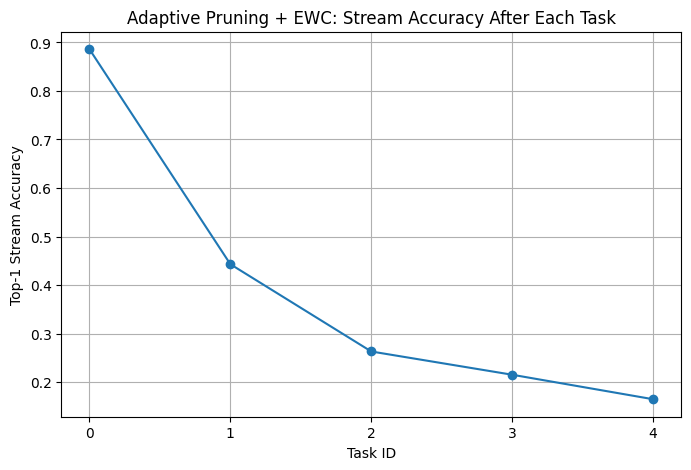

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(adaptive_results["task_id"], adaptive_results["stream_acc"], marker="o")
plt.title("Adaptive Pruning + EWC: Stream Accuracy After Each Task")
plt.xlabel("Task ID")
plt.ylabel("Top-1 Stream Accuracy")
plt.xticks(adaptive_results["task_id"])
plt.grid(True)
plt.show()

Step 17: Plot Loss Graph for Adaptive Pruning + EWC

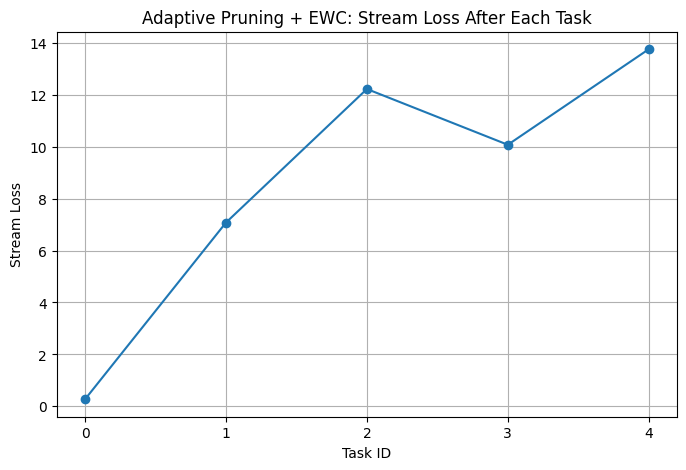

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(adaptive_results["task_id"], adaptive_results["stream_loss"], marker="o")
plt.title("Adaptive Pruning + EWC: Stream Loss After Each Task")
plt.xlabel("Task ID")
plt.ylabel("Stream Loss")
plt.xticks(adaptive_results["task_id"])
plt.grid(True)
plt.show()

Step 18: Plot Sparsity Graph

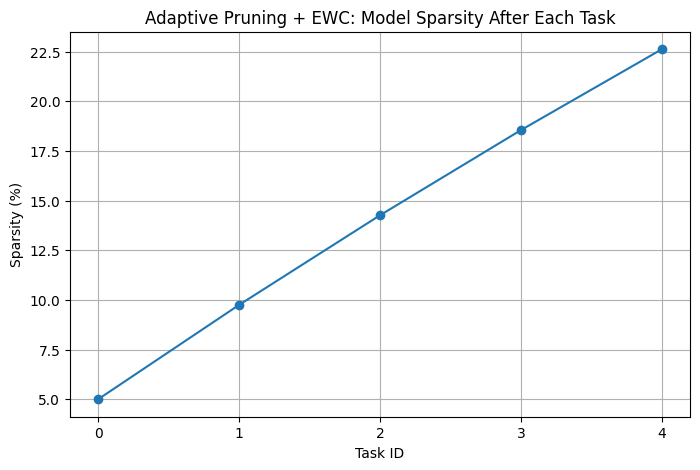

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(adaptive_results["task_id"], adaptive_results["sparsity"], marker="o")
plt.title("Adaptive Pruning + EWC: Model Sparsity After Each Task")
plt.xlabel("Task ID")
plt.ylabel("Sparsity (%)")
plt.xticks(adaptive_results["task_id"])
plt.grid(True)
plt.show()

Step 19: Final Comparison Graph

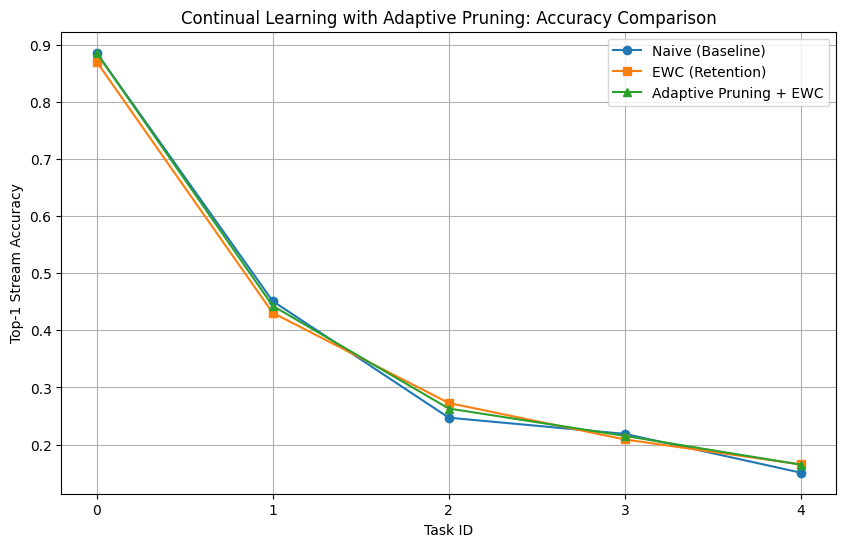

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(naive_results["task_id"], naive_results["stream_acc"], marker="o", label="Naive (Baseline)")
plt.plot(ewc_results["task_id"], ewc_results["stream_acc"], marker="s", label="EWC (Retention)")
plt.plot(adaptive_results["task_id"], adaptive_results["stream_acc"], marker="^", label="Adaptive Pruning + EWC")

plt.title("Continual Learning with Adaptive Pruning: Accuracy Comparison")
plt.xlabel("Task ID")
plt.ylabel("Top-1 Stream Accuracy")
plt.xticks(naive_results["task_id"])
plt.legend()
plt.grid(True)
plt.show()

Step 20: Compare Sparsity Across Models

In [23]:
print("Sparsity Comparison")
print("-" * 40)

print("Naive Model:")
naive_sparsity = check_sparsity(naive_model)

print("EWC Model:")
ewc_sparsity = check_sparsity(ewc_model)

print("Adaptive Pruning + EWC Model:")
adaptive_sparsity = check_sparsity(adaptive_model)

Sparsity Comparison
----------------------------------------
Naive Model:
Model Sparsity: 0.00%
EWC Model:
Model Sparsity: 0.00%
Adaptive Pruning + EWC Model:
Model Sparsity: 22.62%


Step 21: Save All Results

In [25]:
naive_results.to_csv("naive_results.csv", index=False)
ewc_results.to_csv("ewc_results.csv", index=False)
adaptive_results.to_csv("adaptive_pruning_ewc_results.csv", index=False)

print("✓ All results saved successfully")

✓ All results saved successfully
